# Calendar Heatmap

A calendar heatmap draws one colored cell per day, the weeks as columns and the weekdays as rows, so a daily series shows its rhythm at a glance: which day of the week something happens, and in which season. This guide shows how to create calendar heatmaps with the [datachart.charts.CalendarHeatmap](../../../references/charts/calendarheatmap/#datachart.charts.CalendarHeatmap) function, starting with the basics and building up to worked examples on illustrative daily data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-calendar-heatmap), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import CalendarHeatmap

## Basics

The examples in this guide share one dataset: the number of cyclists counted on each day of 2024 by an automatic counter on a city cycle path. The counts are illustrative, drawn from a seeded generator in a hidden cell with the rhythm such a counter records: commuter traffic on weekdays, quieter weekends, a summer peak, rainy days that halve the count, and a week in November when the counter was down. `cyclists` holds the dates and the counts. The rhythm is the point of the chart, and every customization below helps to read it: the weekend rows, the summer columns, and the blank week.

In [2]:
import datetime
import numpy as np


def daily_cyclists(year, seed):
    """Illustrative daily cyclist counts: commuter weekdays, a summer peak, rainy days."""
    rng = np.random.RandomState(seed)
    first = datetime.date(year, 1, 1)
    n_days = (datetime.date(year + 1, 1, 1) - first).days
    dates, counts = [], []
    for i in range(n_days):
        day = first + datetime.timedelta(days=i)
        season = 1 + 0.6 * np.sin((i / n_days - 0.2) * 2 * np.pi)
        base = 900 if day.weekday() < 5 else 450
        count = base * season * rng.normal(1.0, 0.12)
        # a rainy day halves the traffic
        if rng.rand() < 0.15:
            count *= 0.5
        dates.append(day)
        counts.append(int(round(count)))
    return dates, counts


DATES, COUNTS = daily_cyclists(2024, seed=7)
# the counter was down for a week in November: those days are missing
OUTAGE_START = datetime.date(2024, 11, 11)
outage = {OUTAGE_START + datetime.timedelta(days=i) for i in range(7)}
cyclists = {
    "date": [d for d in DATES if d not in outage],
    "value": [c for d, c in zip(DATES, COUNTS) if d not in outage],
}

The data is a dictionary with two lists: `date` holds one temporal object per day (`datetime.date`, `datetime.datetime`, `numpy.datetime64`, or a pandas `Timestamp`; date strings are never parsed), and `value` the number of that day. Every date appears once. A day that is missing from the list, or valued `None`, is drawn as a blank cell, which is how the outage week will show:

In [3]:
list(zip(cyclists["date"][:3], cyclists["value"][:3]))

[(datetime.date(2024, 1, 1), 465),
 (datetime.date(2024, 1, 2), 368),
 (datetime.date(2024, 1, 3), 355)]

**Basic example.** Only the `data` argument is required. Each column is a week and each row a weekday, Monday at the top; the calendar spans the months that hold data, the whole year here. The cells are colored by their value, a stepped line separates the months, which are labelled along the bottom, and every other weekday is labelled on the left. The two pale rows at the bottom are the weekends, the dark columns in the middle are the summer, and the blank column in November is the outage:

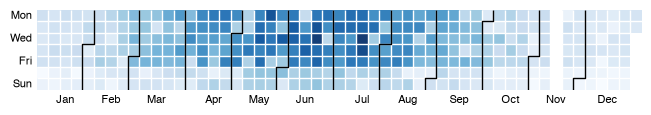

In [4]:
CalendarHeatmap(
    # add the data to the chart
    data=cyclists
).show()

## Customizing the Calendar Heatmap

Every customization is either a keyword argument of `CalendarHeatmap` or a `plot_calendar_heatmap_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title                                 | `title`                                                                 | [Title and figure size](#title-and-figure-size) |
| resize the figure or stretch the cells      | `figsize`, `aspect_ratio`                                               | [Title and figure size](#title-and-figure-size) |
| start the week on Sunday                    | `week_start`                                                            | [Week start](#week-start) |
| hide the month or weekday labels            | `show_month_labels`, `show_weekday_labels`                              | [Month and weekday labels](#month-and-weekday-labels) |
| show and label the colorbar                 | `show_colorbars`, `colorbar`                                            | [Colorbar and cell values](#colorbar-and-cell-values) |
| write the values into the cells             | `show_values`, `value_format`                                           | [Colorbar and cell values](#colorbar-and-cell-values) |
| change the colormap or transparency         | `style={"plot_calendar_heatmap_cmap": ..., "plot_calendar_heatmap_alpha": ...}` | [Calendar style](#calendar-style) |
| style the cell values                       | `style={"plot_calendar_heatmap_font_size": ..., ...}`                   | [Calendar style](#calendar-style) |
| change the cell borders or month separators | `style={"plot_calendar_heatmap_edge_width": ..., "plot_calendar_heatmap_month_line_color": ...}` | [Calendar style](#calendar-style) |
| fix the value range of the colormap         | `vmin`, `vmax`                                                          | [Normalization](#normalization) |
| spread skewed values over the colormap      | `norm`                                                                  | [Normalization](#normalization) |
| center the colors on a neutral value        | `norm="centered"`, `vcenter`                                            | [Normalization](#normalization) |
| highlight one series, mute the rest         | not supported                                                           | [Emphasis](#emphasis) |
| put a note on a day                         | `texts`                                                                 | [Text annotations](#text-annotations) |
| draw several years                          | `data` spanning several years, `max_cols`                               | [One calendar per year](#one-calendar-per-year) |
| draw one year of a longer series            | `year`                                                                  | [The year filter](#the-year-filter) |
| compare several series                      | `data` as a list of dicts, `subtitle`                                   | [Multiple datasets](#multiple-datasets) |
| place a calendar beside other charts        | `Grid`                                                                  | [Composing calendar heatmaps](#composing-calendar-heatmaps) |
| plot dates from numpy or pandas             | `numpy.datetime64` or `Timestamp` objects as `date`                     | [Other date types](#other-date-types) |
| restyle every chart at once                 | `config.set_theme`                                                      | [Themes](#themes) |
| save the chart to a file                    | `save_figure`                                                           | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `week_start` | [`CALENDAR_WEEKDAY`](../../../references/constants/#datachart.constants.CALENDAR_WEEKDAY) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `aspect_ratio` | [`ASPECT_RATIO`](../../../references/constants/#datachart.constants.ASPECT_RATIO) |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `norm` | [`COLOR_NORM`](../../../references/constants/#datachart.constants.COLOR_NORM) |
| `colorbar={"location": ..., "format": ..., "orientation": ...}` | [`COLORBAR_LOCATION`](../../../references/constants/#datachart.constants.COLORBAR_LOCATION), [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`ORIENTATION`](../../../references/constants/#datachart.constants.ORIENTATION) |

The full list of style attributes is in the [datachart.typings.CalendarHeatmapStyleAttrs](../../../references/charts/calendarheatmap/#datachart.typings.CalendarHeatmapStyleAttrs) type; the full list of parameters is in the [datachart.charts.CalendarHeatmap](../../../references/charts/calendarheatmap/#datachart.charts.CalendarHeatmap) reference.

### Title and figure size

A calendar names its own axes, the months and the weekdays, so the one label it needs is a `title` that says what the colors measure. The cells are square by default, which is what makes the chart read as a calendar, and the default figure is wide and short to fit them; `figsize` takes a `(width, height)` tuple in inches or a preset from [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE), and a wider figure means larger cells. `aspect_ratio` decides what happens when the figure does not fit 53 square weeks: [ASPECT_RATIO.EQUAL](../../../references/constants/#datachart.constants.ASPECT_RATIO) (the default) keeps the cells square and leaves the spare space empty, `ASPECT_RATIO.AUTO` stretches them to fill the figure. Stretched cells give a full year more height on a page-wide figure, at the price of the calendar look.

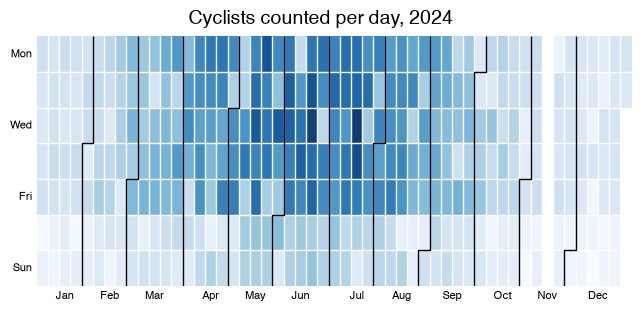

In [5]:
from datachart.constants import FIG_SIZE, ASPECT_RATIO

CalendarHeatmap(
    data=cyclists,
    # add the title
    title="Cyclists counted per day, 2024",
    # a taller figure than the square cells need
    figsize=(6.3, 3.0),
    # stretch the cells to fill it
    aspect_ratio=ASPECT_RATIO.AUTO,
).show()

### Week start

Whether the weekend sits at the bottom of the calendar or wraps around it depends on the day the week starts on. The weeks run from Monday to Sunday by default, which keeps Saturday and Sunday together in the bottom two rows; `week_start` with [CALENDAR_WEEKDAY.SUNDAY](../../../references/constants/#datachart.constants.CALENDAR_WEEKDAY) starts them on Sunday, as American calendars and the GitHub contributions graph do, and the weekend splits into the top and bottom rows. The default comes from the theme's `chart_default_calendar_heatmap_week_start` attribute, so it can be set once for every chart through the [config](../../styling/themes/).

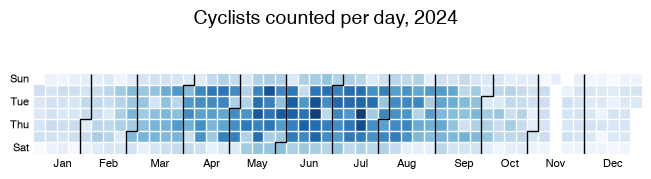

In [6]:
from datachart.constants import CALENDAR_WEEKDAY

CalendarHeatmap(
    data=cyclists,
    # start the weeks on Sunday: the weekend splits into the top and bottom rows
    week_start=CALENDAR_WEEKDAY.SUNDAY,
    title="Cyclists counted per day, 2024",
).show()

### Month and weekday labels

The month labels along the bottom and the weekday labels on the left are the reader's map of the calendar, and the default keeps both: each month over the middle of its weeks, and every other weekday down the side. In a dense figure, a small multiple or a thumbnail, they cost more room than they earn; `show_month_labels=False` and `show_weekday_labels=False` drop them. The month separators stay, so the months still read from the shape.

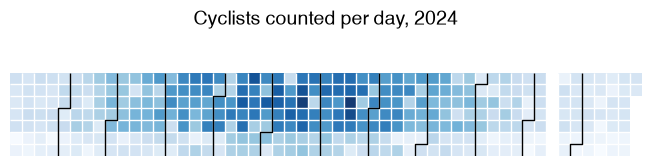

In [7]:
CalendarHeatmap(
    data=cyclists,
    # drop the labels, keep the separators
    show_month_labels=False,
    show_weekday_labels=False,
    title="Cyclists counted per day, 2024",
).show()

### Colorbar and cell values

A calendar on its own shows which days are busier and which are quieter, not by how much. `show_colorbars` draws the colorbar that maps the colors back to values, and `colorbar` says how: a `label` for the unit, a `location` from [COLORBAR_LOCATION](../../../references/constants/#datachart.constants.COLORBAR_LOCATION), a `format` for its tick labels (a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) member or a `"{x:.0f}"` style string), and explicit `ticks`; the fields are listed in [ColorbarSettingAttrs](../../../references/typings/#datachart.typings.ColorbarSettingAttrs). A calendar is wide and short, so a colorbar along the bottom costs the least space.

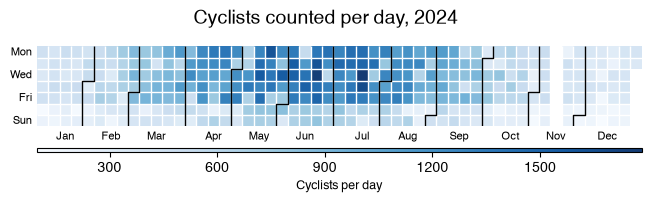

In [8]:
from datachart.constants import COLORBAR_LOCATION, VALUE_FORMAT

CalendarHeatmap(
    data=cyclists,
    title="Cyclists counted per day, 2024",
    # a colorbar along the bottom, labelled and ticked every 300
    show_colorbars=True,
    colorbar={
        "label": "Cyclists per day",
        "location": COLORBAR_LOCATION.BOTTOM,
        "format": VALUE_FORMAT.INTEGER,
        "ticks": [300, 600, 900, 1200, 1500],
    },
).show()

Where the exact numbers matter, `show_values` writes every day's value into its cell and `value_format` formats it, the same way as the colorbar ticks; on dark cells the value is written in white, so it stays legible across the colormap. A year of cells is too small to carry numbers, so the values suit a short span: `winter`, the counts of January and February, draws only those two months, and its cells are large enough to read.

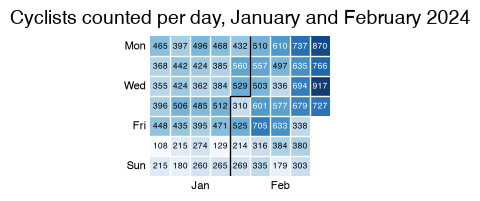

In [9]:
# January and February only: the calendar spans just these two months
winter = {
    "date": [d for d in cyclists["date"] if d.month <= 2],
    "value": [v for d, v in zip(cyclists["date"], cyclists["value"]) if d.month <= 2],
}

CalendarHeatmap(
    data=winter,
    # write the count into every cell
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
    title="Cyclists counted per day, January and February 2024",
).show()

### Calendar style

The `style` dictionary sets the look of the calendar: the colormap and alpha of the cells, the font of the cell values, the borders between the cells, and the separators between the months; the attributes are listed in [datachart.typings.CalendarHeatmapStyleAttrs](../../../references/charts/calendarheatmap/#datachart.typings.CalendarHeatmapStyleAttrs), and any attribute left out keeps the value of the active theme. The colormap is a [COLORS](../../../references/constants/#datachart.constants.COLORS) constant, a single color, a list of hex colors, or a matplotlib colormap, as the [colormaps guide](../../styling/colormaps/) explains; `None` takes the theme's heatmap colormap. The borders are white by default, standing in for the gaps of a printed calendar, and a thin grey border with a heavier, darker month separator turns the calendar into a ruled grid where the months stand out.

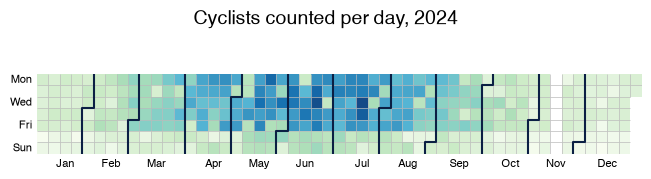

In [10]:
from datachart.constants import COLORS

CalendarHeatmap(
    data=cyclists,
    style={
        # a blue-green colormap
        "plot_calendar_heatmap_cmap": COLORS.GnBu,
        # thin grey borders between the days
        "plot_calendar_heatmap_edge_width": 0.5,
        "plot_calendar_heatmap_edge_color": "#BBBBBB",
        # heavy dark separators between the months
        "plot_calendar_heatmap_month_line_width": 1.5,
        "plot_calendar_heatmap_month_line_color": "#0B1F44",
    },
    title="Cyclists counted per day, 2024",
).show()

### Normalization

The colors come from a two-step mapping: the values are first normalized to the 0–1 range, then each normalized value picks its color from the colormap, exactly as on the [heatmap](../heatmap/#normalization). By default the smallest value maps to the first color and the largest to the last, which is the wrong range for two common questions. When a few extreme days wash out the rest, `vmin` and `vmax` pin the endpoints instead: the days beyond them saturate and the ordinary days spread over the whole colormap. With the range pinned at 0 to 1200, the busiest summer weekdays saturate and the difference between a weekday and a weekend in winter becomes visible.

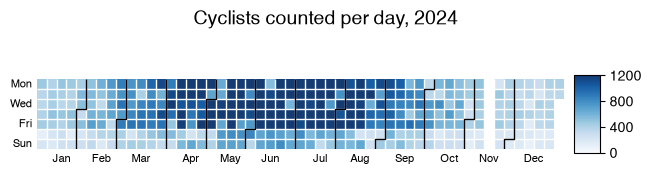

In [11]:
CalendarHeatmap(
    data=cyclists,
    # pin the range: the busiest days saturate, the ordinary days spread out
    vmin=0,
    vmax=1200,
    title="Cyclists counted per day, 2024",
    show_colorbars=True,
    colorbar={"ticks": [0, 400, 800, 1200]},
).show()

When the values are skewed, a few very busy days above many quiet ones, `norm` changes how they spread over the 0–1 range: `"linear"` (the default), `"log"`, `"symlog"`, `"asinh"`, or `"logit"`, as the [COLOR_NORM](../../../references/constants/#datachart.constants.COLOR_NORM) constants name them. `"log"` and `"asinh"` give the low values more of the colormap, so the quiet days stop looking alike; the colorbar ticks show the stretched scale.

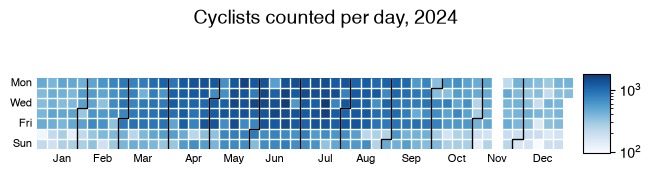

In [12]:
from datachart.constants import COLOR_NORM

CalendarHeatmap(
    data=cyclists,
    # spread the quiet days over more of the colormap
    norm=COLOR_NORM.LOG,
    title="Cyclists counted per day, 2024",
    show_colorbars=True,
).show()

A daily series is often read as a departure from something rather than as a level: how far above or below the usual a day ran. `norm=COLOR_NORM.CENTERED` is for that shape. It holds `vcenter` (zero by default) in the middle of the theme's diverging colormap and runs the same distance to each side, so a day above the baseline and a day equally far below get the same depth in opposite hues, and the neutral middle is exactly the baseline. It also switches the cells from the theme's sequential colormap to its diverging one, `plot_heatmap_cmap_diverging`, which the calendar inherits like the sequential map; a `plot_calendar_heatmap_cmap` in the chart's own `style` still wins.

Subtracting the year's mean from every count turns the cyclist counts into such a series. Winter reads brown, the summer peak purple, and the weekends stand out as the quiet days inside every week.

In [ ]:
# each day as its departure from the year's mean count
mean_count = sum(cyclists["value"]) / len(cyclists["value"])
anomaly = {
    "date": cyclists["date"],
    "value": [v - mean_count for v in cyclists["value"]],
}

CalendarHeatmap(
    data=anomaly,
    # zero, the year's mean, sits in the middle of the diverging colormap
    norm=COLOR_NORM.CENTERED,
    title="Cyclists per day against the 2024 mean",
    show_colorbars=True,
    colorbar={"label": "Departure from the mean"},
).show()

### Emphasis

The other charts accept an `emphasis` attribute that highlights one series and mutes the rest. The calendar heatmap does not: like the heatmap it is a single raster layer, not a set of series, so there is nothing to bring forward or push back, and `CalendarHeatmap` raises a `ValueError` if `emphasis` is passed. To draw attention to part of a calendar, pin the value range so the days of interest saturate, pick a colormap that turns dark at that level, or point at a day with `texts`, as the next section shows; the [highlighting guide](../../styling/highlighting/) covers the charts that take `emphasis`.

### Text annotations

A blank week or a dark column raises a question, and a note answers it on the chart. `texts` places text on the calendar with an optional `target` to draw a connector to a cell; the [Text Annotations](../../utility/annotations/) guide covers placement, connector looks and styling. The cells sit at integer positions: the week column along `x` and the weekday row along `y`, both counted from zero at the top-left cell of the drawn range, which is the week that holds the first day of the first drawn month. Rows count downwards, so `y=-1.5` is above the calendar. A text is anchored at its left edge, and the connector stops inside the cell it points at. The note below explains the blank week in November, its column computed from the outage date.

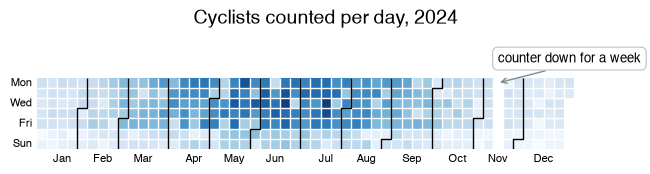

In [13]:
from datachart.constants import ARROW_STYLE

# the outage week's column, counted from the week of 1 January (the first drawn month)
first_drawn = datetime.date(2024, 1, 1)
outage_week = (first_drawn.weekday() + (OUTAGE_START - first_drawn).days) // 7

CalendarHeatmap(
    data=cyclists,
    # a note above the calendar, an arrow down into the blank week
    texts={
        "text": "counter down for a week",
        "x": outage_week,
        "y": -2.4,
        "target": (outage_week, 0),
        "style": {"plot_text_arrow_style": ARROW_STYLE.ARROW},
    },
    title="Cyclists counted per day, 2024",
).show()

## Multiple Calendar Heatmaps

### One calendar per year

The question a second year answers is whether the pattern repeats: the same summer peak, the same weekend rows. Data spanning several years draws one calendar per year, in year order, each subtitled by its year, and the years share one value range, so the same count takes the same color in every calendar (`vmin` and `vmax` still pin the range when set). The `title` is global; `max_cols` limits the calendars per row, one by default, so the years stack and the weeks line up. `two_years` joins a 2023 series from the same generator to the 2024 counts.

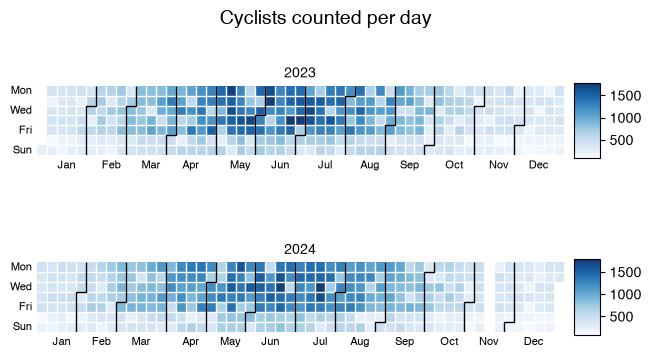

In [14]:
DATES_2023, COUNTS_2023 = daily_cyclists(2023, seed=3)

two_years = {
    "date": DATES_2023 + cyclists["date"],
    "value": COUNTS_2023 + cyclists["value"],
}

CalendarHeatmap(
    # two years of data: one calendar per year, on one value range
    data=two_years,
    title="Cyclists counted per day",
    show_colorbars=True,
).show()

### The year filter

A long series often needs one year drawn on its own, colored over its own values rather than the range of the whole series. `year` keeps that one year; a year with no data raises a `ValueError`.

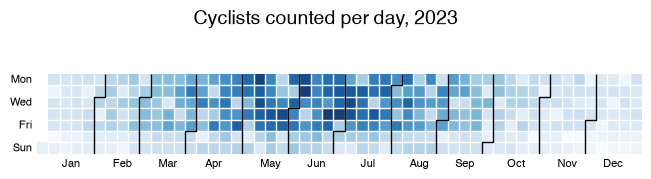

In [15]:
CalendarHeatmap(
    data=two_years,
    # keep one year, colored over its own range
    year=2023,
    title="Cyclists counted per day, 2023",
).show()

### Multiple datasets

To compare several series, pass a list of dictionaries to `data`. Each is drawn in its own calendar, named by its `subtitle`; a dataset spanning several years still splits into one calendar per year, named by the subtitle and the year. The per-calendar attributes, `style`, `norm`, `vmin`, `vmax`, `colorbar` and `texts`, take a list with one entry per dataset, `None` keeping the default for that one. `quieter` is a second counter on a hillside path with less than half the traffic; drawn in its own colormap, each calendar shows its own rhythm rather than the difference in volume.

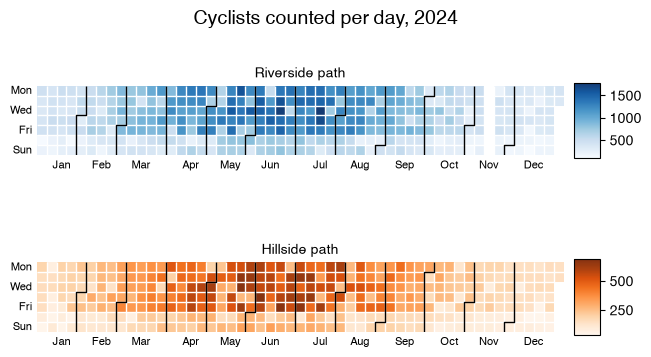

In [16]:
DATES_B, COUNTS_B = daily_cyclists(2024, seed=11)
quieter = {"date": DATES_B, "value": [int(c * 0.4) for c in COUNTS_B]}

CalendarHeatmap(
    # one calendar per dataset
    data=[cyclists, quieter],
    # named by their subtitles
    subtitle=["Riverside path", "Hillside path"],
    # the first keeps the theme colormap, the second gets its own
    style=[None, {"plot_calendar_heatmap_cmap": COLORS.Oranges}],
    title="Cyclists counted per day, 2024",
    show_colorbars=True,
).show()

### Composing calendar heatmaps

A calendar shows the pattern; a second chart puts numbers to it. A calendar owns its axes, the weeks and weekdays are not a coordinate space another chart can share, so [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) rejects a calendar figure. [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges it beside other charts, each in its own cell, and a multi-year calendar keeps its stack of years in its cell; the [Grid](../../utility/grid/) guide covers the layout options. The example sets the calendar over a bar chart of the monthly totals in thousands, so the summer peak can be read as a number.

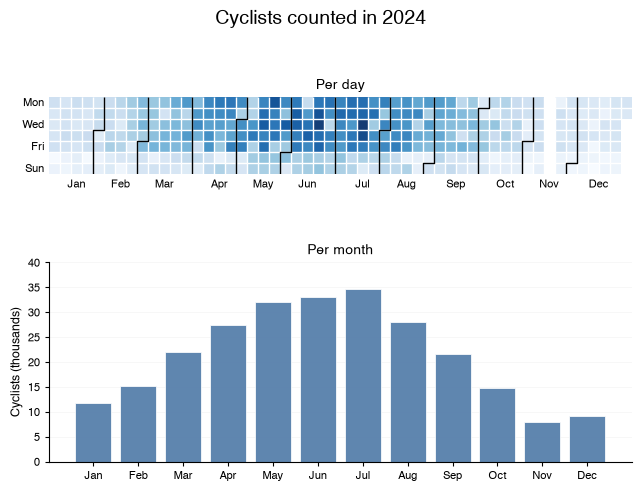

In [17]:
from datachart.charts import BarChart
from datachart.utils import Grid

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly = [
    {"label": name, "y": sum(c for d, c in zip(cyclists["date"], cyclists["value"]) if d.month == m) / 1000}
    for m, name in enumerate(MONTHS, start=1)
]

calendar = CalendarHeatmap(data=cyclists, title="Per day")
totals = BarChart(data=monthly, title="Per month", ylabel="Cyclists (thousands)", ymin=0)

# the calendar over the monthly totals
Grid([[calendar], [totals]], title="Cyclists counted in 2024", figsize=FIG_SIZE.FULL_MEDIUM).show()

## Additional Features

### Other date types

Daily data seldom arrives as `datetime.date` objects: it comes out of numpy as `datetime64` values or out of pandas as `Timestamp` objects, and both are accepted as they are, with the time of day ignored. Date strings are the one thing that is not parsed, so a column of `"2024-01-01"` strings is converted first (`numpy.array(strings, dtype="datetime64[D]")` or `pandas.to_datetime`). `spring` holds the same counter's March to May values on a `datetime64` range:

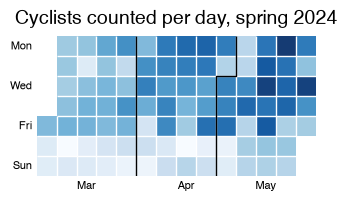

In [18]:
# a numpy date range and the counts that fall in it
days = np.arange("2024-03-01", "2024-06-01", dtype="datetime64[D]")
by_date = dict(zip(cyclists["date"], cyclists["value"]))
spring = {
    "date": list(days),
    "value": [by_date[day.astype(datetime.date)] for day in days],
}

CalendarHeatmap(
    data=spring,
    title="Cyclists counted per day, spring 2024",
).show()

### Themes

A theme sets the colormap, the fonts, the borders and the week start of every calendar at once, so a report's charts match without styling each one. The calendar's colormap follows the theme's heatmap colormap unless `plot_calendar_heatmap_cmap` sets its own. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme) as the [Themes](../../styling/themes/) guide shows; the [Theme Gallery](../../styling/theme-gallery/) shows the whole suite under each theme. Style is resolved when the chart is created, so a theme set before the call and reset after it applies to that chart alone.

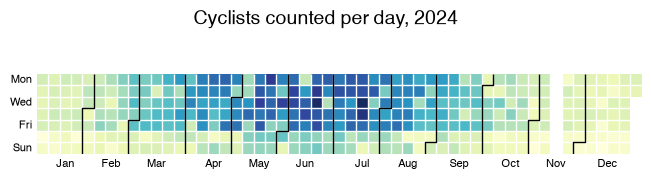

In [19]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.INK)
figure = CalendarHeatmap(data=cyclists, title="Cyclists counted per day, 2024")
config.set_theme(THEME.DEFAULT)
figure.show()

## Real-World Examples

The examples below put the features above to work, each one answering a question about a daily rhythm. The data is illustrative, drawn from seeded generators in hidden cells; each example says what its data stands for.

### Example 1: When Does the Work Get Done? (Sunday Weeks, a Custom Colormap, No Colorbar)

`contributions` holds the number of commits on each day of 2025 by one illustrative developer: a few commits on most weekdays, rarely any at the weekend, and a burst of them in two release weeks in March and September. The calendar is laid out like the GitHub contributions graph, because that is how developers read commit activity: the weeks start on Sunday, the colormap is GitHub's green scale passed as a list of hex colors, the month separators are off, and there is no colorbar, since the graph is read by pattern rather than by value. The release weeks would drown the everyday commits on a linear colormap, so `COLOR_NORM.ASINH` spreads the low counts over the greens. The answer is in the rows: the work happens Monday to Friday, and the two dark columns are the releases.

In [20]:
rng = np.random.RandomState(3)
YEAR = 2025
first_day = datetime.date(YEAR, 1, 1)
n_days = (datetime.date(YEAR + 1, 1, 1) - first_day).days

commit_dates, commit_counts = [], []
for i in range(n_days):
    day = first_day + datetime.timedelta(days=i)
    if day.weekday() < 5:
        commits = int(rng.poisson(2.5)) if rng.rand() < 0.7 else 0
        # release weeks in March and September
        if day.isocalendar()[1] in (11, 37):
            commits += int(rng.poisson(12))
    else:
        commits = int(rng.poisson(0.8)) if rng.rand() < 0.3 else 0
    commit_dates.append(day)
    commit_counts.append(commits)

contributions = {"date": commit_dates, "value": commit_counts}

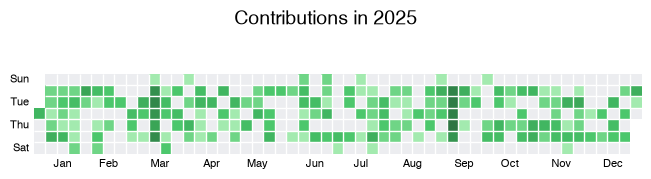

In [21]:
# the green scale of the GitHub contributions graph, from no commits to many
GITHUB_GREENS = ["#ebedf0", "#9be9a8", "#40c463", "#30a14e", "#216e39"]

CalendarHeatmap(
    data=contributions,
    style={
        "plot_calendar_heatmap_cmap": GITHUB_GREENS,
        # the graph has no month separators, only the gaps between the squares
        "plot_calendar_heatmap_month_line_width": 0,
    },
    # spread the everyday counts over the greens despite the release weeks
    norm=COLOR_NORM.ASINH,
    week_start=CALENDAR_WEEKDAY.SUNDAY,
    title=f"Contributions in {YEAR}",
).show()

### Example 2: Which Season Is the Wet One? (Three Years, a Shared Range, Blank Dry Days)

`rainfall` holds the illustrative daily precipitation in millimetres at a station with wet winters and dry summers, over 2022 to 2024. A dry day has no entry at all rather than a zero, so it is drawn blank and only the wet days carry color; the season then reads from the density of the cells as much as from their shade. Three years draw as three stacked calendars on one value range, so a downpour looks the same whichever year it fell in, and the `colorbar` names the unit and prints whole millimetres. The answer repeats three times: the wet cells crowd the winter months at both ends of each calendar and thin out through the summer.

In [22]:
rng = np.random.RandomState(12)
rain_dates, rain_mm = [], []
for year in (2022, 2023, 2024):
    first = datetime.date(year, 1, 1)
    n_days = (datetime.date(year + 1, 1, 1) - first).days
    for i in range(n_days):
        day = first + datetime.timedelta(days=i)
        # wet winters, dry summers
        wet_chance = 0.45 - 0.35 * np.sin((i / n_days - 0.25) * 2 * np.pi)
        if rng.rand() < wet_chance:
            rain_dates.append(day)
            rain_mm.append(round(float(rng.gamma(2.0, 4.0)), 1))

rainfall = {"date": rain_dates, "value": rain_mm}

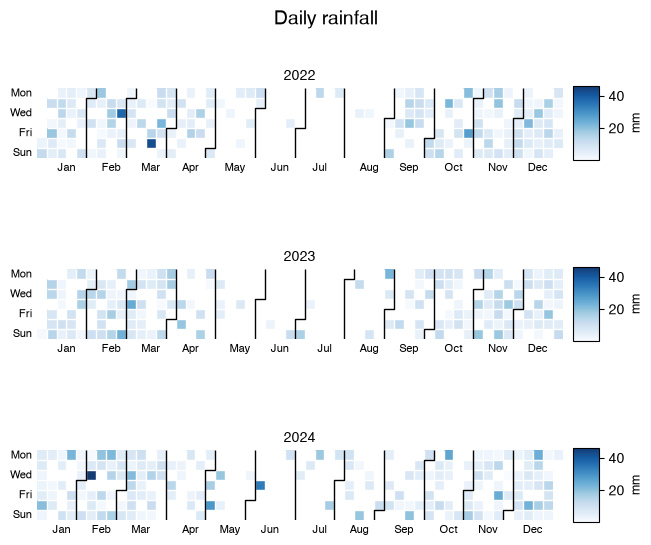

In [23]:
CalendarHeatmap(
    data=rainfall,
    style={"plot_calendar_heatmap_cmap": COLORS.Blues},
    title="Daily rainfall",
    # one colorbar for the three years, in whole millimetres
    show_colorbars=True,
    colorbar={"label": "mm", "format": VALUE_FORMAT.INTEGER},
).show()

### Example 3: Which Day Fills the Shop? (Cell Values, a Note, a Pinned Range, and a Grid)

`footfall` holds the illustrative number of visitors to a shop on each day of the last quarter of 2024: busy Saturdays, a closed Sunday every week, and the run-up to Christmas, and `by_weekday` the mean visitors per weekday over the quarter. The calendar answers the question by row: the values are written into the cells, the range is pinned so the December rush saturates while the ordinary weeks keep their contrast, and a `texts` note above the calendar names the two dark December columns, its target column computed from the first drawn month, October. A bar chart of the weekday means under it puts a number on the Saturday row, with `emphasis_rule` highlighting the busiest day, and [Grid](../../utility/grid/) stacks the two in one figure.

In [24]:
rng = np.random.RandomState(9)
foot_dates, foot_counts = [], []
day = datetime.date(2024, 10, 1)
while day.year == 2024:
    if day.weekday() < 6:
        base = 320 if day.weekday() == 5 else 180
        # the run-up to Christmas
        if datetime.date(2024, 12, 9) <= day <= datetime.date(2024, 12, 24):
            base *= 1.8
        foot_dates.append(day)
        foot_counts.append(int(rng.normal(base, base * 0.1)))
    day += datetime.timedelta(days=1)

footfall = {"date": foot_dates, "value": foot_counts}

WEEKDAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
by_weekday = [
    {"label": name, "y": round(np.mean([c for d, c in zip(foot_dates, foot_counts) if d.weekday() == i]))}
    for i, name in enumerate(WEEKDAYS)
]

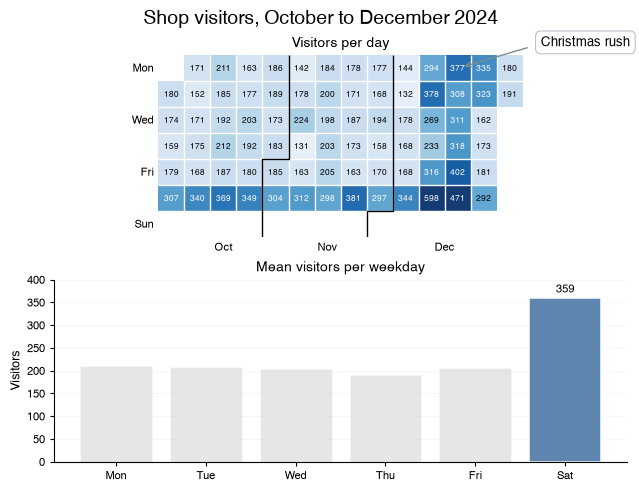

In [25]:
# the second week of the Christmas rush, counted from the week of 1 October
# (the first drawn month)
first_drawn = datetime.date(2024, 10, 1)
rush = datetime.date(2024, 12, 16)
rush_week = (first_drawn.weekday() + (rush - first_drawn).days) // 7

visits = CalendarHeatmap(
    data=footfall,
    title="Visitors per day",
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
    # the Christmas rush saturates, the ordinary weeks keep their contrast
    vmin=100,
    vmax=450,
    texts={
        "text": "Christmas rush",
        # above and to the right, an arrow down onto the Monday cell
        "x": rush_week + 3.2,
        "y": -1,
        "target": (rush_week, 0),
        "style": {"plot_text_arrow_style": ARROW_STYLE.ARROW},
    },
)
weekdays = BarChart(
    data=by_weekday,
    title="Mean visitors per weekday",
    ylabel="Visitors",
    # the busiest day highlighted, the rest muted
    emphasis_rule={"top": 1},
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
    ymin=0,
    ymax=400,
)

Grid([[visits], [weekdays]], title="Shop visitors, October to December 2024", figsize=FIG_SIZE.FULL_MEDIUM).show()